In [1]:
import pandas as pd
import numpy as np


In [14]:
#creating a dataframe for testing our linear regression
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Generate 100 x values (study time)
studytime = np.random.uniform(1, 10, 100)  # random floats between 1 and 10

# Generate y values (score) with some noise
score = 2.5 * studytime + np.random.normal(0, 2, 100)  # linear relation + noise

# Create DataFrame
points = pd.DataFrame({
    'studytime': studytime,
    'score': score
})

In [21]:
#calculating loss function E=(1/n)​i=1∑n​(yi​−y^​i​)2
#only for understandin error function does not effect calculation of m and b
def lossfunction(m,b,points,x_colname,y_colname): #x_colname = column name of values of x,y_colname = column name of values of y
  total_error=0
  for i in range(len(points)):
    x=points.iloc[i][x_colname]
    y=points.iloc[i][y_colname]
    total_error += (y-(m * x +b)) ** 2
  return total_error/float(len(points))




In [16]:
def gradient_descent(m_now,b_now,points,L,x_colname,y_colname):
  m_gradient=0
  b_gradient=0
  n=len(points)
  for i in range(n):
    x=points.iloc[i][x_colname]
    y=points.iloc[i][y_colname]

    m_gradient += -(2/n)*x*(y-(m_now*x+b_now))
    b_gradient += -(2/n)*(y-(m_now*x+b_now))


  m_new=m_now-m_gradient * L
  b_new=b_now-b_gradient * L
  return m_new,b_new


In [17]:
m, b = 0, 0  # initial guess
learning_rate = 0.0001
epochs = 1000

for _ in range(epochs):
    m, b = gradient_descent(m, b, points, learning_rate, 'studytime', 'score')

print(f"Trained m: {m}, b: {b}")



Trained m: 2.4196133724314426, b: 0.37598367661460486


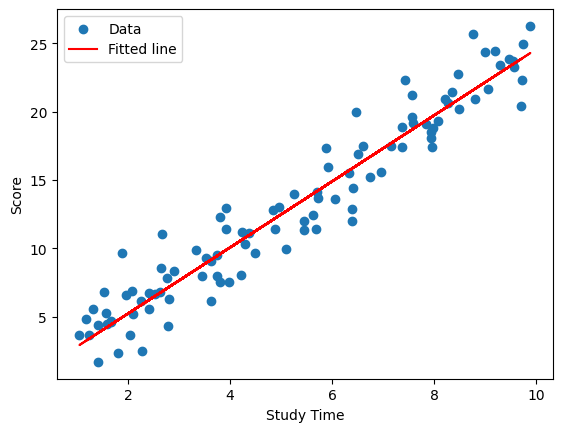

In [18]:
import matplotlib.pyplot as plt

plt.scatter(points['studytime'], points['score'], label='Data')
plt.plot(points['studytime'], m*points['studytime'] + b, color='red', label='Fitted line')
plt.xlabel('Study Time')
plt.ylabel('Score')
plt.legend()
plt.show()


**Overview:**

In this project, we implemented simple linear regression from scratch using Python. We first created a synthetic dataset of 100 points, simulating a linear relationship between studytime and score with some random noise. We then defined a gradient descent function to iteratively update the slope (m) and intercept (b) to minimize the mean squared error. By running the gradient descent for multiple epochs with an appropriate learning rate, the model learned parameters close to the true underlying values (m ≈ 2.5, b ≈ 0). Finally, the trained model can be used to predict scores based on study time and visualized with a fitted line over the data points.